# EDA
- Professor Sambriddhi | CS4200
- Gabriel Jackson | July 31, 2026
# Part I: Dataset Overview

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#For consistent styling across all EDA plots.
sns.set_theme(style="whitegrid", context="notebook")

FEATURES = [f"X{i}" for i in range(1, 17)]
TARGET = "y"
CLASS_NAMES = {
    0: "Healthy",
    1: "Generalized seizure",
    2: "Focal seizure",
    3: "Seizure event",
}
CLASS_ORDER = list(CLASS_NAMES.values())
PALETTE = {
    "Healthy": "#2A9D8F",
    "Generalized seizure": "#E76F51",
    "Focal seizure": "#6A4C93",
    "Seizure event": "#E9C46A",
}

#Loads csv with error handling
data_candidates = [
    Path("BEED_Data.csv")
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place BEED_Data.csv in the same folder as this notebook.")

df = pd.read_csv(data_path)
print("="*100)
print(f"Data file: {data_path.name}")
print(f"Observations: {len(df):,}")
print(f"Variables: {df.shape[1]}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("="*100)

print("\nFirst five observations:")
print(df.head().to_string(index=False))

Data file: BEED_Data.csv
Observations: 8,000
Variables: 17
Shape: (8000, 17)
Columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'y']

First five observations:
  X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  X16  y
   4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   10  0
  87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61  -21  0
-131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40  -14  0
  68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6  -29  0
 -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9  -41  0


- **Dataset name:** Bangalore EEG Epilepsy Dataset (BEED).

- **Data source:** The BEED documentation reports 16,000 original 20-second EEG segments distributed evenly across four categories. The supplied CSV analyzed here contains 8,000 observations—2,000 per class—with 16 EEG-channel variables per observation. The documentation does not fully explain how the reported source segments were converted into the released rows, so the analysis is limited to the CSV structure.

- **Number of observations:** 8,000 rows.

- **Number of variables:** 17 variables: 16 numeric predictors (`X1`–`X16`) and one target (`y`).

- **Target variable:** `y`, with four classes: `0 = Healthy`, `1 = Generalized seizure`, `2 = Focal seizure`, and `3 = Seizure event`.

- **Predictor variables:** `X1`–`X16`, anonymous numeric EEG-channel measurements. The dataset does not map them to named electrodes or brain regions.

- **Classification problem:** The original problem is **multiclass classification**. All four labels are retained during EDA so that differences among the seizure-related classes are not hidden prematurely. Binary healthy-versus-seizure classification remains a later modeling option if the three seizure classes are not sufficiently distinguishable.

# Part II: Data Quality Assessment

In [2]:
print("="*100)
print("Data types:")
print("-"*100)
print(df.dtypes.to_string())

print("="*100)
print("Missing values per column:")
print("-"*100)
print(df.isna().sum().to_string())
print(f"Total missing values: {int(df.isna().sum().sum())}")

#Checks exact duplicates and rows for repeated predictor values.
full_duplicates = int(df.duplicated().sum())
predictor_duplicates = int(df.duplicated(subset=FEATURES).sum())
print(f"Fully duplicated rows: {full_duplicates}")
print(f"Rows duplicating all predictor values: {predictor_duplicates}")
print("="*100)

print(f"Observed target variable values: {sorted(df[TARGET].unique().tolist())}")
numeric_values = df[FEATURES].to_numpy()
print(f"Predictor minimum: {numeric_values.min()}")
print(f"Predictor maximum: {numeric_values.max()}")
print("="*100)

#IQR flag to identify outlier values
outlier_counts = {}
for channel in FEATURES:
    q1, q3 = df[channel].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[channel] = int(((df[channel] < lower) | (df[channel] > upper)).sum())

outlier_summary = pd.Series(outlier_counts, name="IQR-flagged values").sort_values(ascending=False)
flagged_total = int(outlier_summary.sum())
flagged_percent = 100 * flagged_total / (len(df) * len(FEATURES))
print("Outlier Summary:")
print("-"*100)
print(outlier_summary.to_string())
print(f"Total IQR-flagged predictor values: {flagged_total:,} ({flagged_percent:.2f}%)")

Data types:
----------------------------------------------------------------------------------------------------
X1     int64
X2     int64
X3     int64
X4     int64
X5     int64
X6     int64
X7     int64
X8     int64
X9     int64
X10    int64
X11    int64
X12    int64
X13    int64
X14    int64
X15    int64
X16    int64
y      int64
Missing values per column:
----------------------------------------------------------------------------------------------------
X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
y      0
Total missing values: 0
Fully duplicated rows: 0
Rows duplicating all predictor values: 0
Observed target variable values: [0, 1, 2, 3]
Predictor minimum: -323
Predictor maximum: 296
Outlier Summary:
----------------------------------------------------------------------------------------------------
X11    1680
X9     1613
X16    1574
X3     1564
X1     1550
X8     1519
X7     1444


- **Missing values:** None were found, so imputation is unnecessary.

- **Duplicate records:** No full-row or predictor-level duplicates were found, so no observations need to be removed.

- **Data types:** All predictors and the target are integers. No type conversion or categorical encoding is required.

- **Invalid or inconsistent values:** The target contains only the four expected labels, with exactly 2,000 observations per class. No infinite predictor values were found.

- **Outliers:** The IQR rule flags many extreme values. They are retained because EEG measurements may legitimately be extreme and the dataset provides no error rule that would justify deletion.

- **Effect on later analysis:** The CSV requires very little cleaning. The unclear relationship between the 16,000 reported source segments and 8,000 released observations, plus the absence of subject or recording identifiers, limits physiological interpretation and prevents verification of patient-independent splitting.

# Part III: Data Cleaning & Preprocessing (20 points)

In [3]:
#Preserves the original four-class target for exploratory analysis.
clean_df = df[FEATURES + [TARGET]].copy()
# Adds readable class names for tables and visualizations.
clean_df["Class"] = clean_df[TARGET].map(CLASS_NAMES)

X = clean_df[FEATURES].copy()
y = clean_df[TARGET].copy()

print(f"Prepared predictor matrix X: {X.shape}")
print(f"Prepared multiclass target y: {y.shape}")
print("\nRetained class counts:")
print(y.value_counts().sort_index().rename(index=CLASS_NAMES).to_string())
print(f"\nMissing values after preparation: {int(clean_df.isna().sum().sum())}")
print(f"Duplicate rows after preparation: {int(clean_df[FEATURES + [TARGET]].duplicated().sum())}")

Prepared predictor matrix X: (8000, 16)
Prepared multiclass target y: (8000,)

Retained class counts:
y
Healthy                2000
Generalized seizure    2000
Focal seizure          2000
Seizure event          2000

Missing values after preparation: 0
Duplicate rows after preparation: 0


- **Target handling:** The original four-class target is retained. Collapsing classes `1`–`3` now would hide potentially useful differences before they are explored. A binary target can still be created later if EDA and model evaluation show that seizure subtypes cannot be separated reliably.

- **Missing values and duplicates:** None were found, so no imputation or row removal was performed.

- **Categorical encoding:** Not required. `X1`–`X16` are numeric, and the integer target labels already represent the four outcome categories.

- **Standardization:** The main EDA uses raw channel values. A separate standardized copy is created only inside the PCA cell because PCA is variance-based. If Logistic Regression is tested later, scaling must be fitted within each training fold; Random Forest would not require scaling.

- **Train/test split:** No classifier is trained in this EDA notebook, so no split is performed here. The later modeling phase should use a stratified train/test split or stratified cross-validation. Because all four classes currently contain 2,000 rows, stratification will preserve their balanced proportions.

- **Feature engineering:** No engineered variables are added at this stage. All 16 original channels are retained so the EDA can first establish their class distributions and relationships.

- **Leakage prevention:** Subject and recording identifiers are unavailable. A later row-level split could place observations from the same person or recording in both training and test sets. Therefore, results are observation-level performance rather than medical generalizations.

# Part IV: Exploratory Data Analysis & Interpretation (35 points)


Class-specific means:
                        X1     X2     X3     X4     X5     X6     X7     X8     X9    X10    X11    X12    X13    X14    X15    X16
Class                                                                                                                              
Healthy             -12.86 -12.33 -12.23 -12.30 -12.47 -12.23 -12.27 -12.59 -13.35 -13.63 -13.70 -13.87 -14.36 -14.74 -14.73 -14.83
Generalized seizure   7.06   3.63   0.07  -3.70   6.02   2.70  -0.87  -0.76   6.63   3.75   0.27  -4.85   5.55   3.65  -1.81  -1.61
Focal seizure        -0.74   0.12  -0.45  -0.64  -0.97  -0.06  -0.45  -0.21  -0.10  -0.52  -0.36  -0.35  -0.32  -0.37  -0.67   0.04
Seizure event         0.58  -0.18  -0.34   0.16   0.13   0.33   0.00  -0.23   0.23   0.16  -0.31  -0.06   0.48  -0.18  -0.22  -0.05

Class-specific standard deviations:
                        X1     X2     X3     X4     X5     X6     X7     X8     X9    X10    X11    X12    X13    X14    X15    X16
Class            

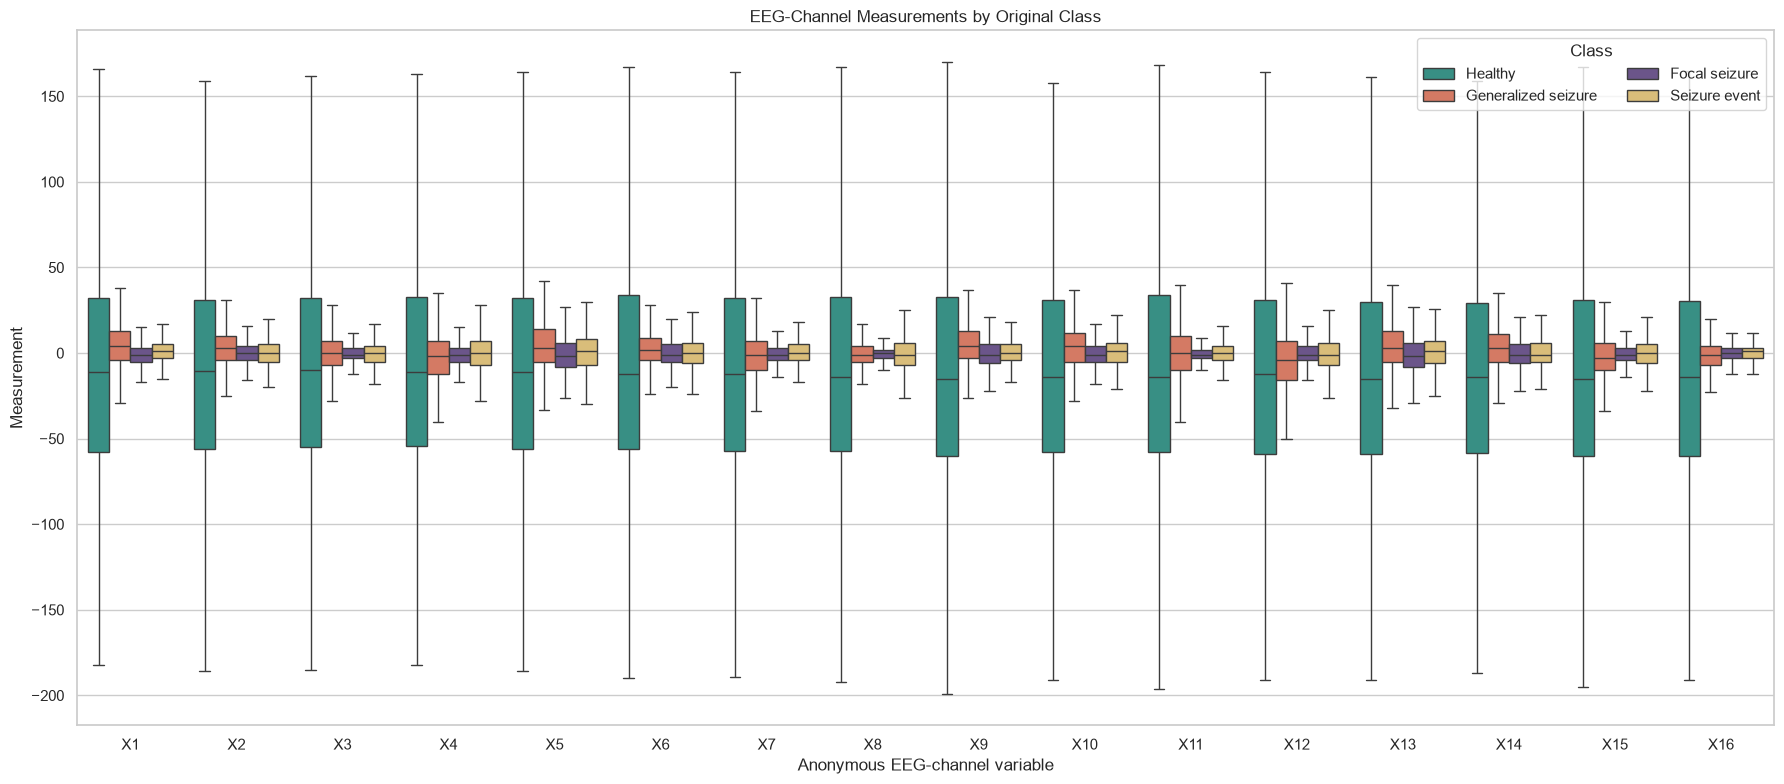

In [4]:
#Summarizes each class before comparing their distributions visually.
class_means = clean_df.groupby("Class", observed=True)[FEATURES].mean().reindex(CLASS_ORDER)
class_stds = clean_df.groupby("Class", observed=True)[FEATURES].std().reindex(CLASS_ORDER)

print("Class-specific means:")
print(class_means.round(2).to_string())
print("\nClass-specific standard deviations:")
print(class_stds.round(2).to_string())

#Reshapes the channel columns so they can share one grouped boxplot.
long_df = clean_df.melt(
    id_vars="Class",
    value_vars=FEATURES,
    var_name="Channel",
    value_name="Measurement",
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=long_df,
    x="Channel",
    y="Measurement",
    hue="Class",
    hue_order=CLASS_ORDER,
    palette=PALETTE,
    showfliers=False,
    ax=ax,
)
ax.set_title("EEG-Channel Measurements by Original Class")
ax.set_xlabel("Anonymous EEG-channel variable")
ax.legend(title="Class", ncols=2)
plt.tight_layout()
plt.show()

**Boxplot interpretation:** The four classes differ mainly in location and spread rather than through a single separating cutoff. Healthy observations have by far the widest distributions across all 16 variables and means near −12 to −15. Generalized-seizure observations are narrower than healthy observations but generally wider than focal-seizure and seizure-event observations. Focal-seizure and seizure-event distributions are the most compact and overlap heavily near zero. Within the generalized-seizure class, variables such as `X1`, `X5`, `X12`, and `X13` show relatively large spreads. These are descriptive dataset patterns only: a boxplot summarizes rows and cannot show whether an EEG signal is temporally “erratic,” and the anonymous channel labels cannot be tied to brain regions.

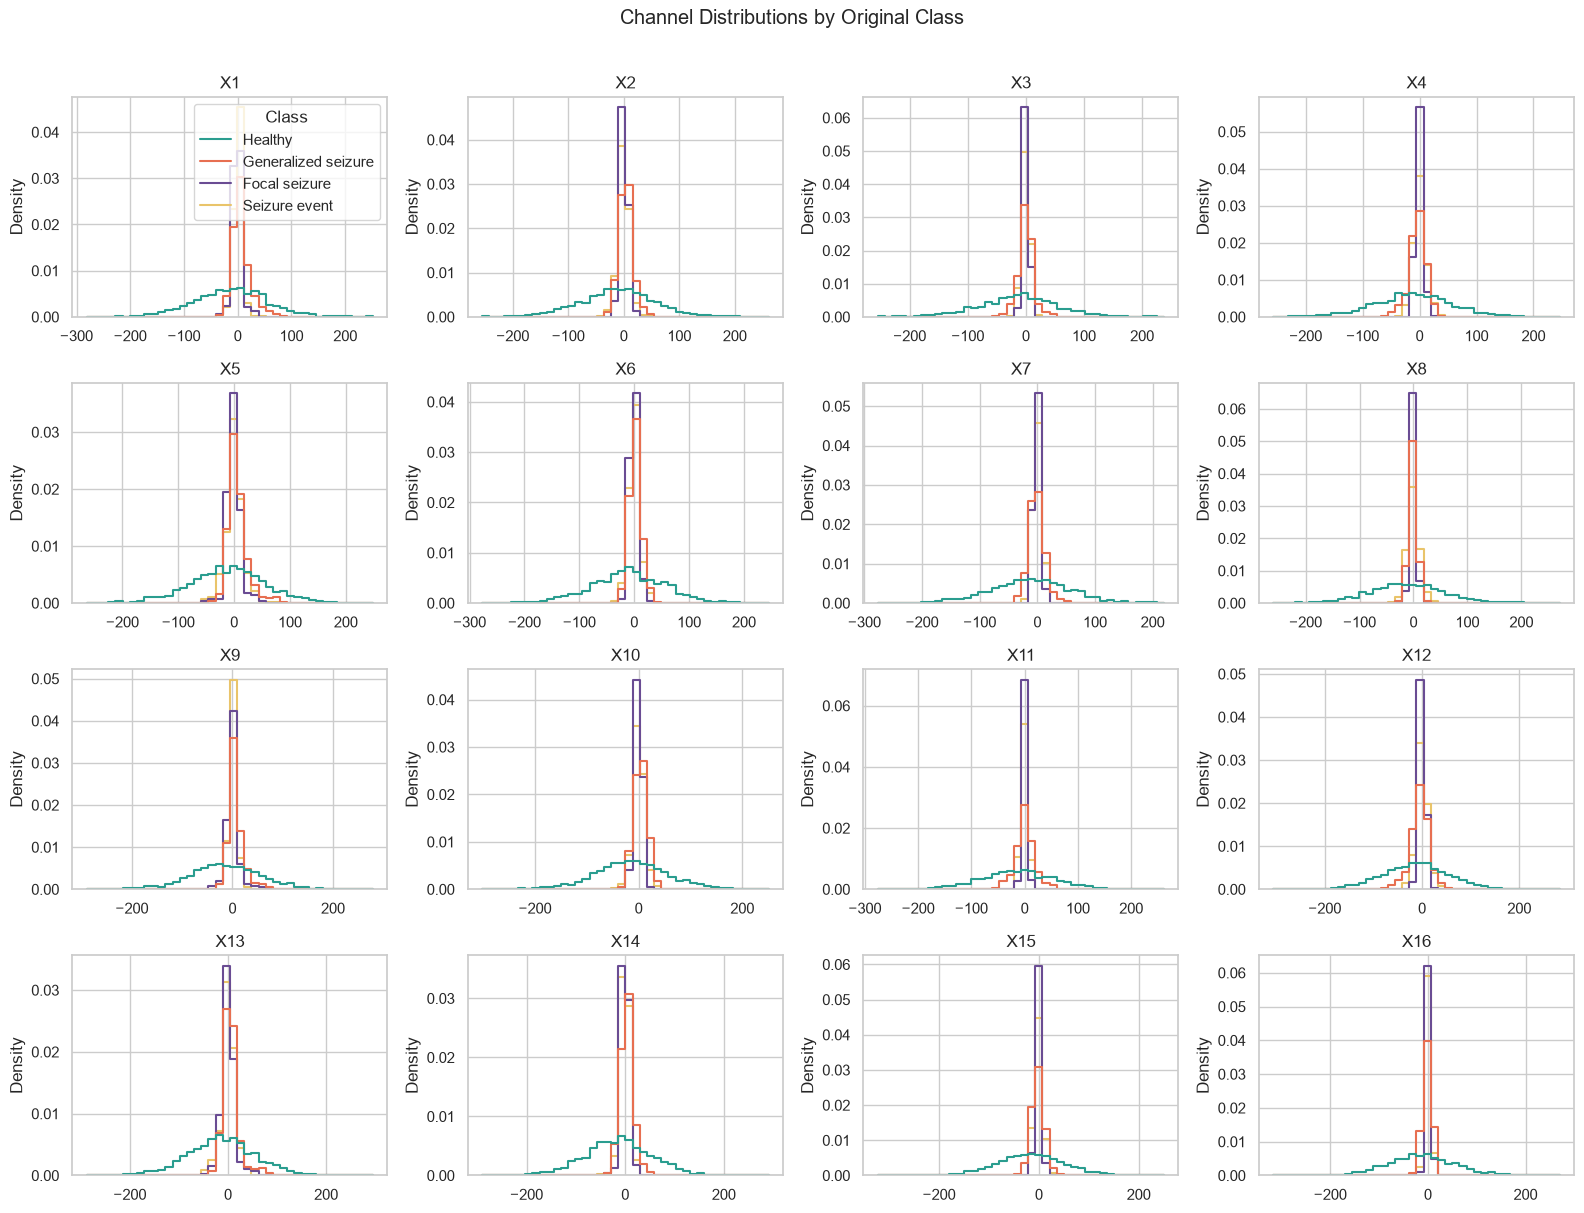

In [5]:
#Shows Channel distributions by all four classes.
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharey=False)
for channel, ax in zip(FEATURES, axes.flat):
    sns.histplot(
        data=clean_df,
        x=channel,
        hue="Class",
        hue_order=CLASS_ORDER,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        palette=PALETTE,
        legend=(channel == "X1"),
        ax=ax,
    )
    ax.set_title(channel)
    ax.set_xlabel("")

fig.suptitle("Channel Distributions by Original Class", y=1.01)
plt.tight_layout()
plt.show()

**Distribution interpretation:** Healthy observations show the heaviest tails and widest ranges on every channel. Generalized-seizure observations form narrower distributions, while focal-seizure and seizure-event observations form the sharpest peaks near zero and overlap substantially. The healthy class also has a modest negative shift, while the other classes are generally closer to zero. This suggests that multichannel magnitude and spread may help distinguish healthy observations from seizure-related observations. Separating the three seizure-related classes appears more difficult—especially focal seizure versus seizure event—so multiclass feasibility must be tested later rather than assumed from these plots.

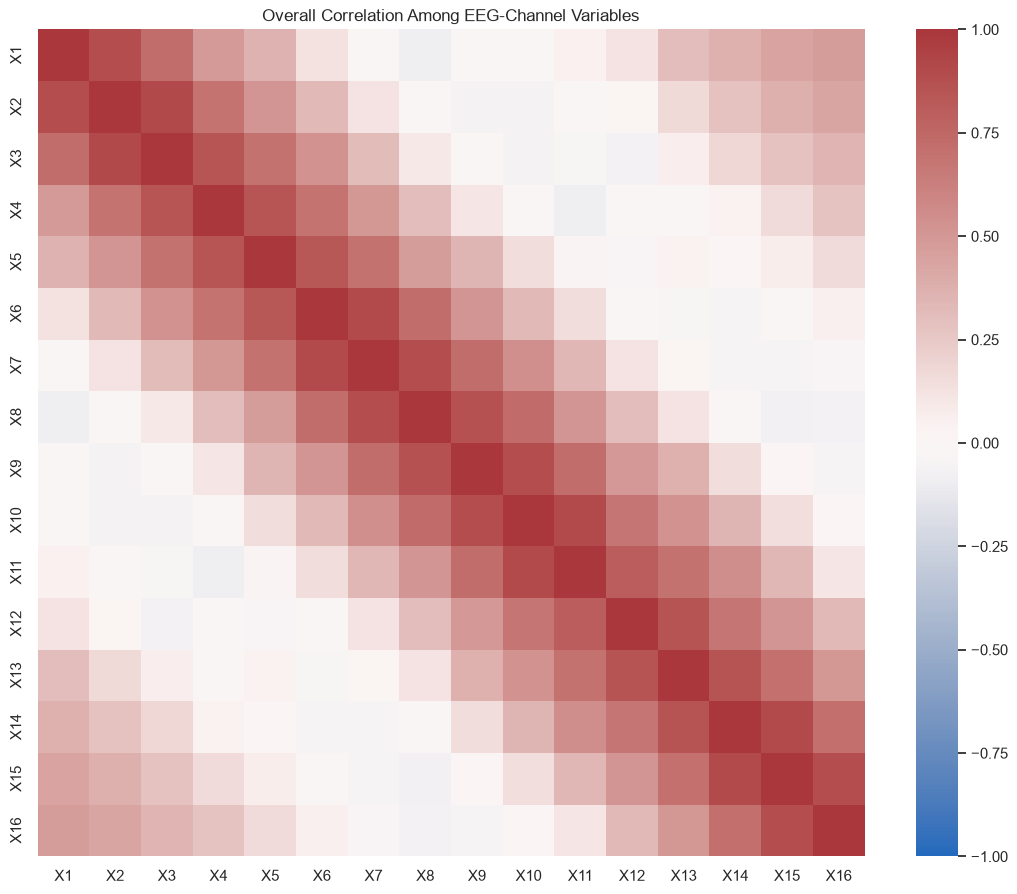

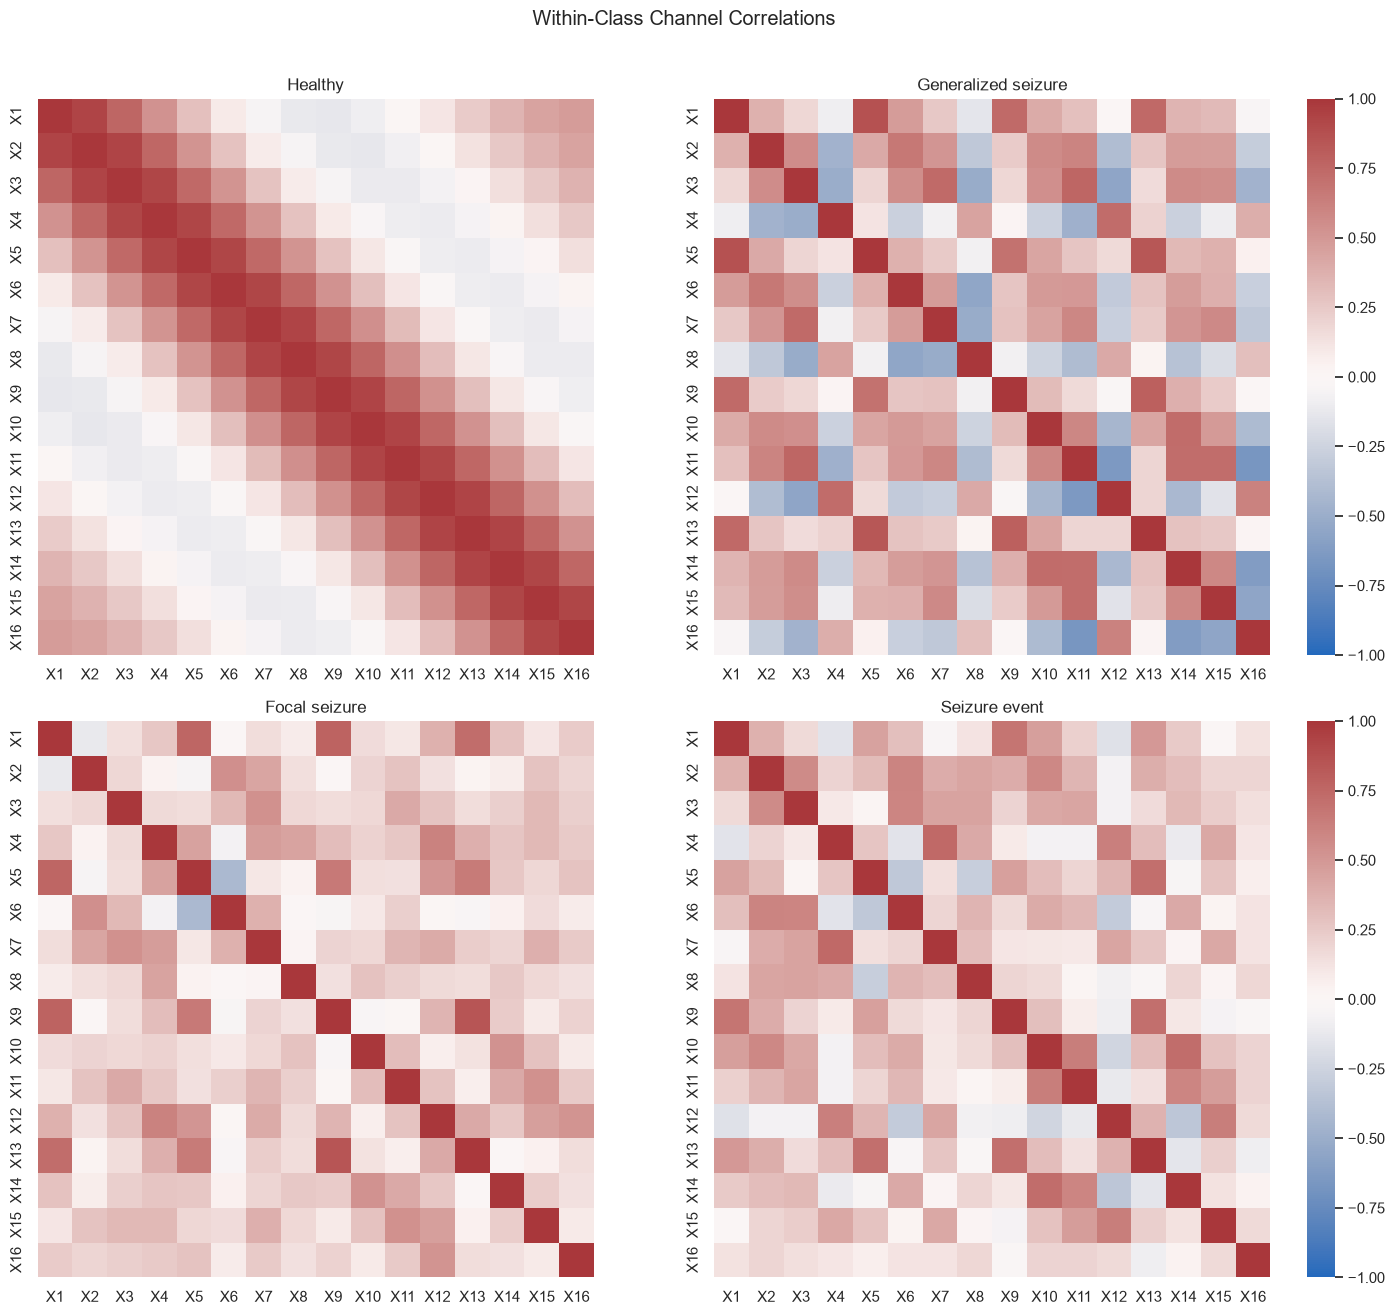

In [6]:
#Overall correlation heatmap among channel variables.
overall_corr = clean_df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(overall_corr, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Overall Correlation Among EEG-Channel Variables")
plt.tight_layout()
plt.show()

#Tests whether the overall Class-specific heatmap pattern remains within each class.
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
for (label, name), ax in zip(CLASS_NAMES.items(), axes.flat):
    class_corr = clean_df.loc[clean_df[TARGET] == label, FEATURES].corr()
    sns.heatmap(
        class_corr,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        cbar=(label in (1, 3)),
        ax=ax,
    )
    ax.set_title(name)
fig.suptitle("Within-Class Channel Correlations", y=1.01)
plt.tight_layout()
plt.show()

**Correlation interpretation:** The diagonal in every heatmap is automatically 1 because each variable is perfectly correlated with itself. Meaningful off-diagonal relationships remain within each class, but their strengths and patterns vary across the four groups. This shows that the overall heatmap is not evidence that every channel has the same “linearity,” nor can close column numbers be treated as temporal or anatomical neighbors. Strong within-class correlations suggest overlapping predictor information. They may make multinomial Logistic Regression coefficients less stable and can divide Random Forest importance across correlated variables, so any importance ranking must be interpreted cautiously.

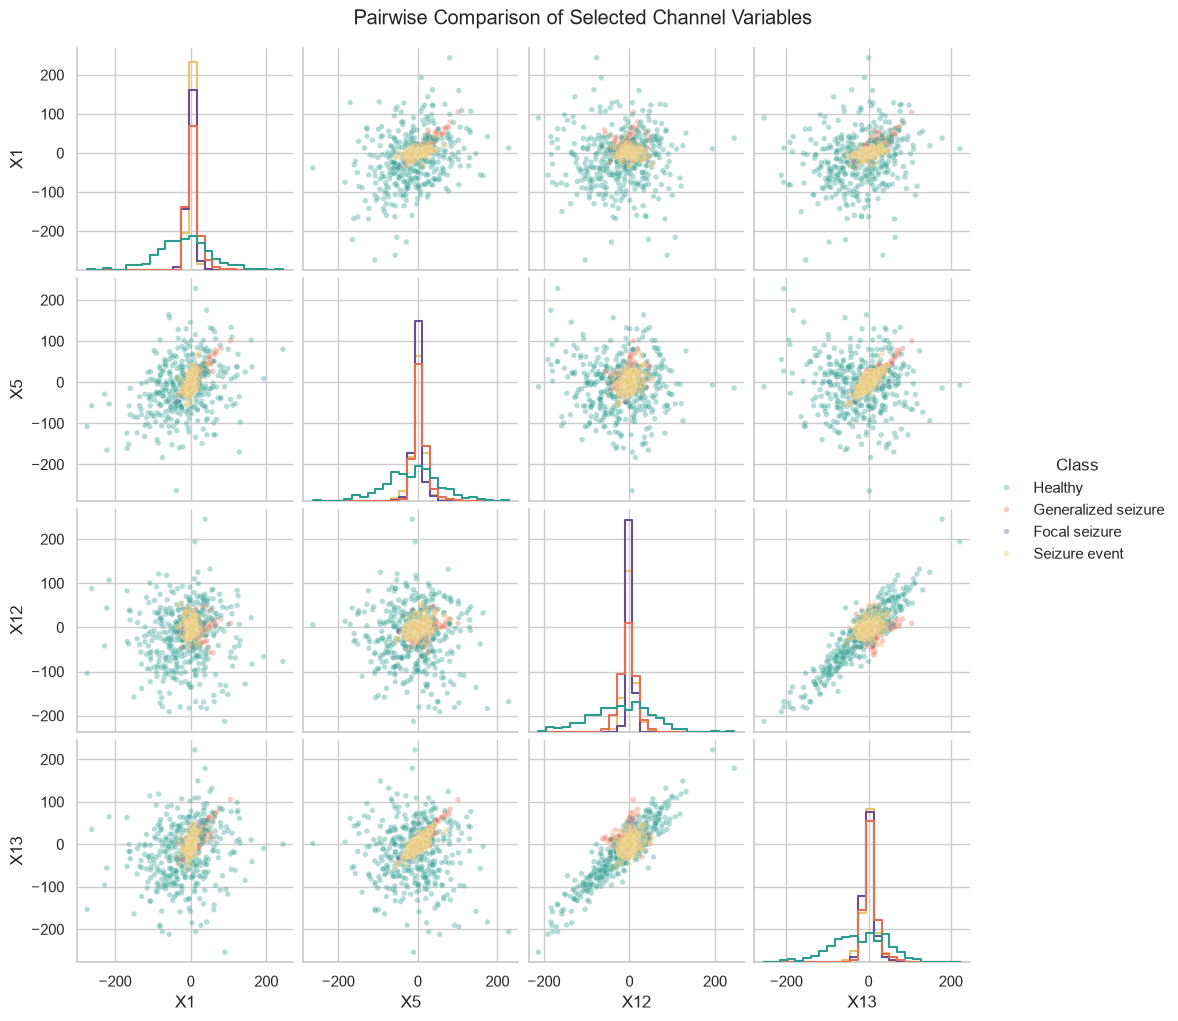

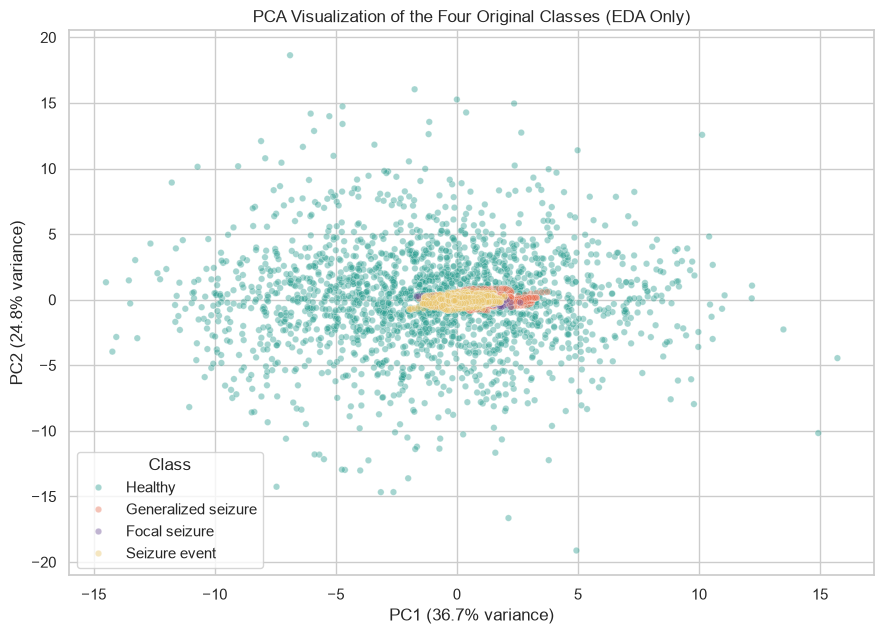

Variance explained by PC1: 36.7%
Variance explained by PC2: 24.8%
Combined variance explained: 61.5%


In [7]:
#Uses the same sample size per class to keep the pairplot readable and balanced.
pair_channels = ["X1", "X5", "X12", "X13"]
pair_sample = (
    clean_df.groupby("Class", group_keys=False, observed=True)
    .sample(n=375, random_state=42)
)

grid = sns.pairplot(
    pair_sample,
    vars=pair_channels,
    hue="Class",
    hue_order=CLASS_ORDER,
    palette=PALETTE,
    diag_kind="hist",
    plot_kws={"alpha": 0.35, "s": 16},
    diag_kws={"bins": 25, "element": "step", "fill": False},
)
grid.fig.suptitle("Pairwise Comparison of Selected Channel Variables", y=1.02)
plt.show()

# PCA is standardized separately and used only for an EDA visualization.
pca_scaled = StandardScaler().fit_transform(clean_df[FEATURES])
pca = PCA(n_components=2)
coordinates = pca.fit_transform(pca_scaled)
explained = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame({
    "PC1": coordinates[:, 0],
    "PC2": coordinates[:, 1],
    "Class": clean_df["Class"].to_numpy(),
})

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Class",
    hue_order=CLASS_ORDER,
    palette=PALETTE,
    alpha=0.42,
    s=22,
    ax=ax,
)
ax.set(
    title="PCA Visualization of the Four Original Classes (EDA Only)",
    xlabel=f"PC1 ({explained[0]:.1f}% variance)",
    ylabel=f"PC2 ({explained[1]:.1f}% variance)",
)
ax.legend(title="Class")
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {explained[0]:.1f}%")
print(f"Variance explained by PC2: {explained[1]:.1f}%")
print(f"Combined variance explained: {explained.sum():.1f}%")

**Pairwise-comparison interpretation:** The selected pairs show a large, diffuse healthy cloud and progressively tighter seizure-related groups. Generalized-seizure observations usually occupy a broader region than focal-seizure and seizure-event observations. The focal and seizure-event points overlap strongly, indicating that these pairs alone are unlikely to separate those two classes reliably. The sloped point patterns within some panels also support correlation among channels, but they do not establish temporal order or brain-region adjacency.

**PCA interpretation:** PC1 and PC2 explain approximately 36.7% and 24.8% of the standardized predictor variance, or about 61.5% combined. Healthy observations form the broadest cloud and are shifted mainly along PC1. The three seizure-related classes are much more compact near the center; generalized seizures are somewhat more dispersed, while focal seizures and seizure events overlap heavily. PCA therefore supports the possibility of distinguishing healthy from seizure-related observations, but it does not show clean four-class separation. Because PCA is unsupervised and 38.5% of the variance lies outside this two-dimensional view, classification performance must be evaluated with supervised models rather than inferred from this plot.

# Part V: Engineering Discussion (20 points)

### Overall findings and informative variables

The main EDA pattern is a multichannel difference in location and spread. Healthy observations have the widest distributions and a modest negative shift, generalized seizures are less dispersed, and focal seizures and seizure events are the most compact and overlap substantially. The unexpectedly wide healthy class should be reported only as a pattern in the provided CSV because the transformation of the original EEG recordings is not fully documented. Several predictors are correlated within classes, but the anonymous channel labels do not support temporal, spatial, or anatomical interpretations. `X1`, `X5`, `X12`, and `X13` visibly illustrate class-specific differences in spread, although EDA alone cannot establish a final feature ranking.

### Variables that may be removed

No variables should be removed based on EDA alone. Strong correlations of channels may improve classification or interact with other predictors. During modeling, the complete 16-variable set can be compared with reduced feature sets using the same cross-validation procedure.

### Feature-engineering opportunities

Possible row-level features include mean absolute magnitude, standard deviation, minimum, maximum, and range across the 16 channel values. These features may capture the class-spread patterns observed during EDA, but they should be compared with the original predictors to determine whether they improve classification. Temporal features such as rolling differences, zero-crossing rate, FFT, and frequency-band power are not justified because the CSV does not provide a documented time sequence within each row.

### Class-imbalance concerns

There is no class imbalance if the original four-class target is retained because each class contains 2,000 observations. Therefore, a majority-class Dummy Classifier would achieve approximately 25% accuracy. If classes `1`–`3` are later combined, the resulting binary target would have a 3:1 imbalance. In that case, an always-seizure prediction would achieve 75% accuracy, so balanced accuracy, class-specific precision and recall, F1-scores, ROC-AUC, and a confusion matrix would be more informative than accuracy alone.

### Leakage and generalization limits

The dataset does not provide subject or recording identifier, so a row-level split might place observations from the same source in both the training and testing sets. At most, the results can support observation-level classification, but will not be reliable enough for broad medical predictions on unseen patients.

### Appropriate models and preprocessing

- **Dummy Classifier:** Provides a no-skill baseline against which trained models can be compared.
- **Multinomial Logistic Regression:** Provides an interpretable linear baseline. Predictor scaling should occur inside the training pipeline, although correlations among channels may make individual coefficients unstable.
- **Random Forest:** Can capture nonlinear thresholds and interactions suggested by the differences in class distributions. It does not require predictor scaling, although correlated predictors may divide feature importance among themselves.

*Overall, the EDA does not confirm that any model will classify the observations successfully and reaffirms my proposals plan to test Multinomial Logistic Regression and Random Forest against a Dummy Classifier. Since focal-seizure and seizure-event observations overlap substantially, the modeling phase should compare four-class classification with a secondary binary healthy-versus-seizure formulation. Then, the final target and model should be chosen using cross-validation and held-out test results rather than visual separation alone.*